In [1]:
import sys
print(sys.executable)

C:\Users\amehr\miniconda3\envs\mining-ai\python.exe


In [4]:
import sys
import blastdesign

Diameter sensitivity comparison. Hole diameter varies from 181 to 311 mm; the other reference inputs remain fixed. The upper panel shows seven deterministic burden-model outputs. The lower panel shows the difference between the largest and smallest output at each sampled diameter. The dashed line marks the 251 mm reference case. This range is model disagreement—not a confidence interval or a validated design recommendation.

Figure saved to: F:\Projects\BlastDesign-AI\docs\figures\diameter_sensitivity_comparison.png


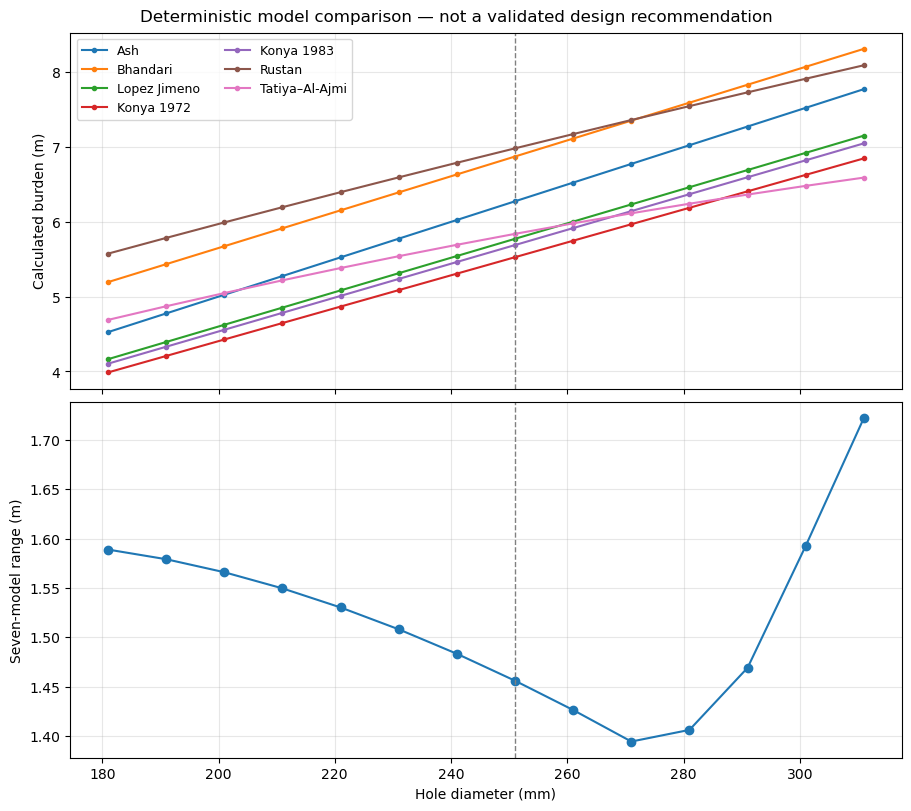

In [2]:
import matplotlib.pyplot as plt

from blastdesign import (
    build_gole_gohar_diameter_sensitivity_table,
    build_diameter_ensemble_summary,
)

sensitivity = build_gole_gohar_diameter_sensitivity_table()
ensemble = build_diameter_ensemble_summary(sensitivity)

fig, (models_ax, spread_ax) = plt.subplots(
    2, 1, figsize=(9, 8), sharex=True, constrained_layout=True
)

for _, group in sensitivity.groupby("model_id", sort=False):
    models_ax.plot(
        group["hole_diameter_mm"],
        group["burden_m"],
        marker=".",
        label=group["model_name"].iloc[0],
    )

models_ax.axvline(251, color="gray", linestyle="--", linewidth=1)
models_ax.set_ylabel("Calculated burden (m)")
models_ax.legend(ncol=2, fontsize=9)
models_ax.grid(alpha=0.3)

spread_ax.plot(
    ensemble["hole_diameter_mm"],
    ensemble["range_m"],
    marker="o",
)
spread_ax.axvline(251, color="gray", linestyle="--", linewidth=1)
spread_ax.set_xlabel("Hole diameter (mm)")
spread_ax.set_ylabel("Seven-model range (m)")
spread_ax.grid(alpha=0.3)

fig.suptitle(
    "Deterministic model comparison — not a validated design recommendation"
)
from pathlib import Path

figure_directory = Path("../docs/figures")
figure_directory.mkdir(parents=True, exist_ok=True)

figure_path = figure_directory / "diameter_sensitivity_comparison.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Figure saved to: {figure_path.resolve()}")
plt.show()